## Data Cleaning and Dataset Preparation

This notebook performs cleaning, standardization, feature preparation, and dataset validation.

- Financial news: text quality filtering and company alignment
- Fake/real news: label validation and duplicate removal
- Market data: financial variable standardization

The objective is to create consistent datasets suitable for NLP modelling
and financial impact analysis.

## Load Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
RAW_PATH = "data/raw"
PROCESSED_PATH = "data/processed"

os.makedirs(PROCESSED_PATH, exist_ok=True)

# Load datasets
financial_news_df = pd.read_csv(
    f"{RAW_PATH}/financial_news.csv"
)

fake_real_df = pd.read_csv(
    f"{RAW_PATH}/fake_real_news.csv"
)

market_df = pd.read_csv(
    f"{RAW_PATH}/market_data.csv"
)


print("Financial News:", financial_news_df.shape)
print("Fake/Real News:", fake_real_df.shape)
print("Market Data:", market_df.shape)

Financial News: (325, 5)
Fake/Real News: (44898, 5)
Market Data: (3200, 12)


## Clean Financial News Dataset

The financial news dataset is inspected for missing values, duplicate observations, and low-quality records.

In [ ]:
# Check missing values
financial_news_df.isnull().sum()

,0
company_ticker,0
publication_date,0
title,0
article_text,0
source,0


The dataset was inspected for missing values in all variables.

Records with missing article text were removed because they cannot
provide meaningful linguistic information for NLP models.

Articles without textual content would negatively affect feature extraction
and classification performance.

In [ ]:
# Remove missing values
financial_news_clean = financial_news_df.copy()


financial_news_clean = financial_news_clean.dropna(
    subset=["article_text"]
)

print(financial_news_clean.shape)

(325, 5)


In [ ]:
# Remove empty articles
financial_news_clean = financial_news_clean[
    financial_news_clean["article_text"]
    .astype(str)
    .str.strip()
    .ne("")
]

In [ ]:
# Remove duplicates
print(
    "Duplicates:",
    financial_news_clean.duplicated(
        subset=["title"]
    ).sum()
)

financial_news_clean = financial_news_clean.drop_duplicates(
    subset=["title"]
)

Duplicates: 45


Duplicate articles were removed to prevent repeated information from influencing later analysis and model training.

Removing duplicates helps ensure that each observation contributes unique information to the dataset.

In [ ]:
# Remove very short articles (<20 words)
financial_news_clean["word_count"] = (
    financial_news_clean["article_text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

In [ ]:
financial_news_clean["word_count"].describe()

,word_count
count,280.000000
mean,38.764286
std,25.806034
min,5.000000
25%,18.750000
50%,30.500000
75%,56.000000
max,225.000000


Articles containing fewer than 20 words were excluded.

Very short articles often contain insufficient contextual information and may introduce noise into NLP-based analyses.

In [ ]:
# Filter
financial_news_clean = financial_news_clean[
    financial_news_clean["word_count"] >= 20
]

In [ ]:
financial_news_clean.shape

(201, 6)

In [ ]:
financial_news_clean.to_csv(
    f"{PROCESSED_PATH}/financial_news_clean.csv",
    index=False
)

**Standardize Dates**

In [ ]:
# Convert
financial_news_clean["publication_date"] = pd.to_datetime(
    financial_news_clean["publication_date"]
)

In [ ]:
# Keep only date
financial_news_clean["publication_date"] = (
    financial_news_clean["publication_date"]
    .dt.date
)

In [ ]:
financial_news_clean.head()

,company_ticker,publication_date,title,article_text,source,word_count
0,AAPL,2026-06-22,Memory's price surge threatens Apple's 'magic ...,Wall Street Journal technology reporter Rolfe ...,Yahoo Finance Video,28
1,AAPL,2026-06-23,"Ranking the ""Magnificent Seven"" From Most to L...","Among Nvidia, Alphabet, Apple, Microsoft, Amaz...",Motley Fool,21
2,AAPL,2026-06-23,Jim Cramer Discusses President Trump’s Big Ann...,We recently published Jim Cramer Discussed Exp...,Insider Monkey,56
3,AAPL,2026-06-23,Does Elon Musk represent a new form of capital...,"LONDON, June 23 (Reuters Breakingviews) - Foll...",Reuters,29
4,AAPL,2026-06-22,What Dell Stock's AI Order Book Revealed Befor...,"Before the stock more than tripled, the compan...",Trefis,25


In [ ]:
financial_news_clean.to_csv(
    f"{PROCESSED_PATH}/financial_news_clean.csv",
    index=False
)

Publication dates were converted into a consistent datetime format.

Standardized dates are necessary for linking financial news articles with corresponding market observations.

**Company / Ticker Mapping**

In [ ]:
# Create mapping from company name to ticker symbol
company_mapping = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "TSLA": "Tesla",
    "NVDA": "NVIDIA",
    "AMZN": "Amazon",
    "GOOGL": "Alphabet",
    "META": "Meta",
    "NFLX": "Netflix",
    "AMD": "Advanced Micro Devices",
    "INTC": "Intel",
    "JPM": "JPMorgan Chase",
    "BAC": "Bank of America",
    "GS": "Goldman Sachs",
    "MS": "Morgan Stanley",
    "C": "Citigroup",
    "WMT": "Walmart",
    "COST": "Costco",
    "HD": "Home Depot",
    "TGT": "Target",
    "DIS": "Disney",
    "UBER": "Uber",
    "CRM": "Salesforce",
    "ORCL": "Oracle",
    "KO": "Coca-Cola",
    "PEP": "PepsiCo",
    "MCD": "McDonald's",
    "NKE": "Nike",
    "XOM": "ExxonMobil",
    "CVX": "Chevron",
    "PFE": "Pfizer",
    "JNJ": "Johnson & Johnson",
    "PYPL": "PayPal",
    "SQ": "Block"
}


In [ ]:
# Add company column
financial_news_clean["company"] = (
    financial_news_clean["company_ticker"]
    .map(company_mapping)
)

In [ ]:
# Rename ticker
financial_news_clean.rename(
    columns={
        "company_ticker":"ticker"
    },
    inplace=True
)

In [ ]:
financial_news_clean[
    ["company","ticker"]
].head()

,company,ticker
0,Apple,AAPL
1,Apple,AAPL
2,Apple,AAPL
3,Apple,AAPL
4,Apple,AAPL


Mapping articles to company ticker symbols allows integration with
historical market data.

This enables later experiments analysing whether textual information
provides additional predictive signals for financial movements.

In [ ]:
financial_news_clean.to_csv(
    f"{PROCESSED_PATH}/financial_news_mapped.csv",
    index=False
)

## Clean Fake & Real News Dataset

The benchmark misinformation dataset was inspected to verify data quality, label consistency, and class balance before model development.

In [ ]:
# Inspect
fake_real_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [ ]:
# Missing values
fake_real_df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
# Remove missing values
fake_real_clean = fake_real_df.dropna(
    subset=[
        "text",
        "label"
    ]
)

In [ ]:
# Remove duplicates
print(
    "Duplicates:",
    fake_real_clean.duplicated(
        subset=["text"]
    ).sum()
)

fake_real_clean = fake_real_clean.drop_duplicates(
    subset=["text"]
)

Duplicates: 6252


In [ ]:
fake_real_clean["label"].value_counts()

,count
label,
real,21192
fake,17454


The original dataset contains two classes:
- real financial/news articles
- misinformation articles

These labels are retained as the target variable for supervised
classification models.

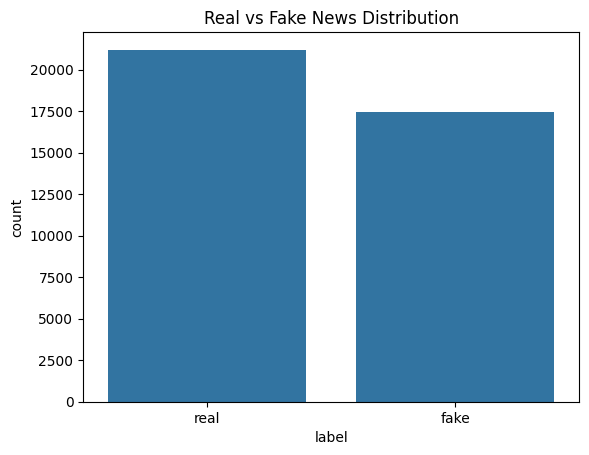

In [ ]:
# Plot fake vs real news distribution
sns.countplot(
    data=fake_real_clean,
    x="label"
)

plt.title(
    "Real vs Fake News Distribution"
)

plt.show()

The distribution of real and fake news articles was examined to assess class balance.

A relatively balanced dataset is beneficial for supervised learning because it reduces the risk of model bias toward a dominant class.

In [ ]:
fake_real_clean.to_csv(
    f"{PROCESSED_PATH}/fake_real_news_clean.csv",
    index=False
)

## Clean Market Dataset

The financial market dataset was prepared for economic analysis by creating derived variables and verifying the completeness of stock market observations.

In [ ]:
# Inspect
market_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            3200 non-null   object 
 1   Close           3200 non-null   float64
 2   High            3200 non-null   float64
 3   Low             3200 non-null   float64
 4   Open            3200 non-null   float64
 5   Volume          3200 non-null   float64
 6   company_ticker  3200 non-null   object 
 7   Adj Close       0 non-null      float64
 8   daily_return    3168 non-null   float64
 9   volatility      2560 non-null   float64
 10  future_return   3168 non-null   float64
 11  future_volume   3168 non-null   float64
dtypes: float64(10), object(2)
memory usage: 300.1+ KB


In [ ]:
market_df = market_df[
    [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "company_ticker",
        "daily_return",
        "volatility"
    ]
]

In [ ]:
# Convert date to datetime
market_df["Date"] = pd.to_datetime(
    market_df["Date"]
)

In [ ]:
# Sort by company and date
market_df = market_df.sort_values(
    ["company_ticker", "Date"]
)

**Daily Return**

In [ ]:
market_df["daily_return"] = (
    market_df
    .groupby("company_ticker")["Close"]
    .pct_change()
)

Daily stock returns were calculated using percentage changes in closing prices.
Returns provide a standardized measure of market performance and are commonly used in financial analysis.

**Volatility**

In [ ]:
# 30-day rolling volatility
market_df["volatility"] = (
    market_df
    .groupby("company_ticker")["daily_return"]
    .transform(
        lambda x:
        x.rolling(30).std()
    )
)

In [ ]:
# Remove NaN values
market_df = market_df.dropna()

In [ ]:
market_df["company_ticker"].unique()

array(['AAPL', 'AMD', 'AMZN', 'BAC', 'C', 'COST', 'CRM', 'CVX', 'DIS',
       'GOOGL', 'GS', 'HD', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'META',
       'MS', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PYPL',
       'TGT', 'TSLA', 'UBER', 'WMT', 'XOM'], dtype=object)

Rolling volatility was calculated using historical daily returns.


In [ ]:
market_df.to_csv(
    f"{PROCESSED_PATH}/market_data_clean.csv",
    index=False
)

Market variables are transformed into modelling features.

Closing prices are converted into daily returns because returns provide
a comparable measure across companies with different price ranges.
Volatility captures short-term market uncertainty.

## Dataset Statistics

Summary statistics were generated to document the final characteristics of the cleaned datasets.

In [ ]:
# Create summary table
stats = []

In [ ]:
# Financial news
stats.append({
    "Dataset":"Financial News",
    "Observations":len(financial_news_clean),
    "Variables":financial_news_clean.shape[1],
    "Extra":"Average words = "
    +str(round(financial_news_clean["word_count"].mean(),2))
})

In [ ]:
# Fake news
stats.append({
    "Dataset":"Fake Real News",
    "Observations":len(fake_real_clean),
    "Variables":fake_real_clean.shape[1],
    "Extra":
    str(fake_real_clean["label"].value_counts().to_dict())
})

In [ ]:
# Market
stats.append({
    "Dataset":"Market Data",
    "Observations":len(market_df),
    "Variables":market_df.shape[1],
    "Extra":
    str(market_df["company_ticker"].unique())
})

In [ ]:
# Create dataframe
dataset_statistics = pd.DataFrame(stats)

dataset_statistics

,Dataset,Observations,Variables,Extra
0,Financial News,201,7,Average words = 48.23
1,Fake Real News,38646,5,"{'real': 21192, 'fake': 17454}"
2,Market Data,2240,9,['AAPL' 'AMD' 'AMZN' 'BAC' 'C' 'COST' 'CRM' 'C...


The final statistics confirm that the processed datasets contain:
- sufficient text samples for NLP analysis
- balanced misinformation labels
- structured market observations

These processed datasets are used in subsequent modelling stages.

In [ ]:
dataset_statistics.to_csv(
    f"{PROCESSED_PATH}/dataset_statistics.csv",
    index=False
)

The processed datasets provide the foundation for synthetic misinformation
generation, detection model development, and financial impact analysis.